In [19]:
import numpy as np
import matplotlib.pyplot as plt

from linear import LinearEmulator
from nonlinear import NonLinearEmulator
from stitching import MGEmulator

In [ ]:

k_nl = np.load(
    "/Users/ajiv/CCL/pyccl/emulators/multi_bin_emulator/k.npy"
)

linear = LinearEmulator(
    "/Users/ajiv/CCL/pyccl/emulators/data/mg_multibin_nn/linear_boost_nn_multibin.pt"
)

nonlinear = NonLinearEmulator(
    "/Users/ajiv/CCL/pyccl/emulators/data/mg_multibin_nn/multibin_nn_emulator.pt",
    k_nl
)



emu = MGEmulator(
    linear,
    nonlinear
)

10
(10, 1024)
[0.32058351 0.04777709 0.6977839  0.98448356 3.06970988 1.00085614
 0.99976148 1.00042199 1.00031791 0.9994059  0.87284615]


/opt/homebrew/Caskroom/miniconda/base/envs/ccl_env/lib/python3.11/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator PCA from version 1.5.2 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [21]:
omega_m = 0.315
omega_b = 0.05
h       = 0.70
n_s     = 0.96

A_s = 3.05

mus = [
    1.1,
    1.1,
    1.1,
    1.1,
    1.1
]

etas = [
    1.1,
    1.1,
    0.92,
    0.97,
    0.99
]

zs = [0.0, 0.5, 1.0]

In [22]:
k_plot = np.logspace(-4, 1., 500)

boost_lin = np.array([

    linear.predict(
        omega_m=omega_m,
        omega_b=omega_b,
        h=h,
        n_s=n_s,
        ln1e10As=A_s,
        mus=mus,
        etas=etas,
        z_pk=z,
        k=k_plot
    )

    for z in zs

])

boost_nl = nonlinear.predict(
    zs=zs,
    omega_m=omega_m,
    omega_b=omega_b,
    h=h,
    n_s=n_s,
    A_s=A_s,
    mus=mus,
    k=k_plot
)

[[ 0.99846303  4.2622194   2.6785345   0.9042645   1.793469   -5.3863506
  -1.7400521  -0.01085067  3.1577682  -2.1860256 ]
 [ 0.9644307   2.9418526   2.1072392   0.08378193 -1.9787701  -0.48589873
  -0.21836683 -0.26459214 -1.311281    0.7977766 ]
 [ 1.0612127   2.2406635   0.89240277 -1.4660408  -3.1410515   1.8904375
  -0.18638028  1.7994896  -0.43459976  0.81363714]]
[1.09449562 1.09399543 1.09348033 1.09324103 1.09282816 1.09290912
 1.09418718 1.09590689 1.09652839 1.0967209 ]


In [23]:
k_stitch, boost_stitch = emu.predict(

    zs=zs,

    omega_m=omega_m,
    omega_b=omega_b,
    h=h,
    n_s=n_s,
    A_s=A_s,

    mus=mus,
    etas=etas,

    k=k_plot
)

[[ 0.99846303  4.2622194   2.6785345   0.9042645   1.793469   -5.3863506
  -1.7400521  -0.01085067  3.1577682  -2.1860256 ]
 [ 0.9644307   2.9418526   2.1072392   0.08378193 -1.9787701  -0.48589873
  -0.21836683 -0.26459214 -1.311281    0.7977766 ]
 [ 1.0612127   2.2406635   0.89240277 -1.4660408  -3.1410515   1.8904375
  -0.18638028  1.7994896  -0.43459976  0.81363714]]
[1.09449562 1.09399543 1.09348033 1.09324103 1.09282816 1.09290912
 1.09418718 1.09590689 1.09652839 1.0967209 ]


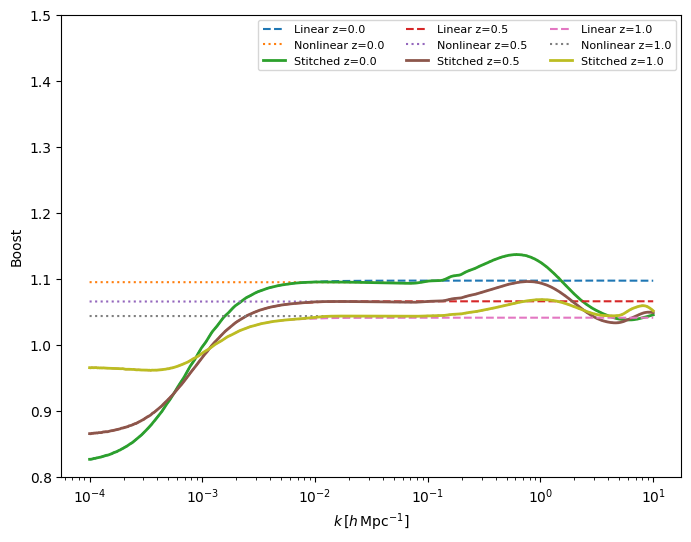

In [24]:
fig, ax = plt.subplots(
    figsize=(8,6)
)

for i, z in enumerate(zs):

    ax.semilogx(
        k_plot,
        boost_lin[i],
        '--',
        label=f'Linear z={z}'
    )

    ax.semilogx(
        k_plot,
        boost_nl[i],
        ':',
        label=f'Nonlinear z={z}'
    )

    ax.semilogx(
        k_plot,
        boost_stitch[i],
        '-',
        linewidth=2,
        label=f'Stitched z={z}'
    )

ax.set_xlabel(r"$k\,[h\,{\rm Mpc}^{-1}]$")
ax.set_ylabel("Boost")

plt.ylim(0.8, 1.5)

ax.legend(
    fontsize=8,
    ncol=3
)

plt.show()

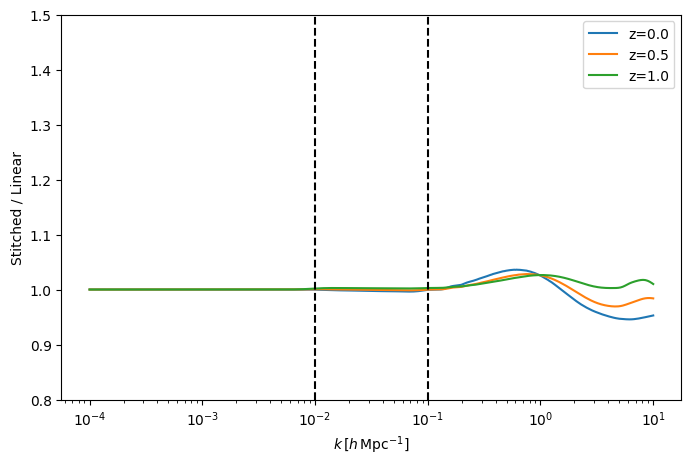

In [25]:
fig, ax = plt.subplots(
    figsize=(8,5)
)

for i, z in enumerate(zs):

    ax.semilogx(
        

        k_plot,

        boost_stitch[i] /
        boost_lin[i],

        label=f"z={z}"

    )

ax.axvline(
    1e-2,
    color='k',
    ls='--'
)

ax.axvline(
    1e-1,
    color='k',
    ls='--'
)

ax.set_ylabel(
    "Stitched / Linear"
)

ax.set_xlabel(
    r"$k\,[h\,{\rm Mpc}^{-1}]$"
)
plt.ylim(0.8, 1.5)

ax.legend()

plt.show()

[[ 1.0186412   4.282921    2.7272928   1.0139911   1.7352493  -5.445962
  -1.7804071   0.08103213  3.4901087  -2.4830713 ]]
[1.09447772 1.0939664  1.09345033 1.09322688 1.09281906 1.09292258
 1.09425177 1.09603119 1.09667468 1.09688193]


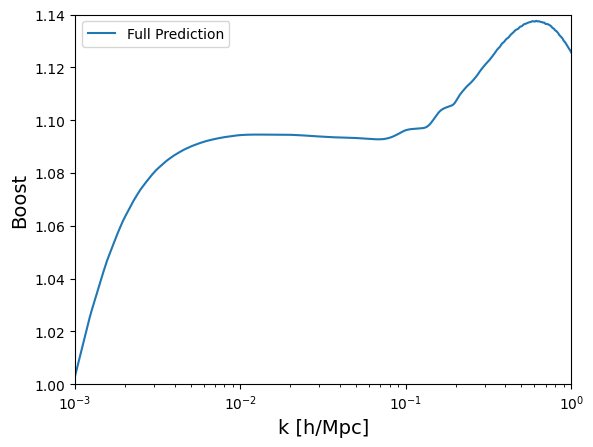

In [32]:
#params = np.load('/home/sankarshana/Codes/cola_emulation/multi_bin_emulation/parameter_samples_augmented.npy')


k, pred = emu.predict(

    zs=0.,

    omega_m=0.3,
    omega_b=0.049,
    h=0.7,
    n_s=0.96,
    A_s=3.05,

    mus=[1.1,1.1,1.1,1.1,1.1],
    etas=[1.0,1.0,1.0,1.0,1.0]
)



plt.semilogx(k, pred[0], label='Full Prediction')
plt.ylabel("Boost", fontsize = 14)
plt.xlabel("k [h/Mpc]", fontsize = 14)
plt.xlim(1e-3,1)
plt.ylim(1,1.14)
plt.legend()


7.650000805799586
0.9851441515264094


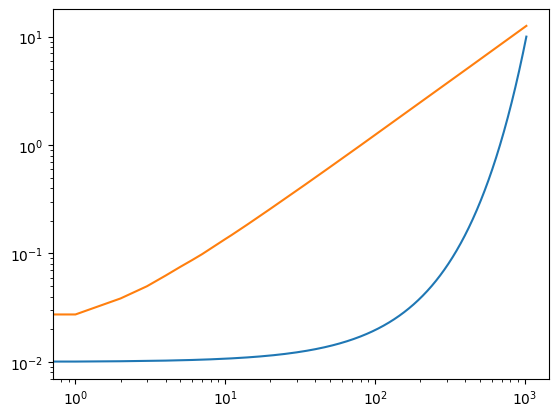

In [27]:
#print(k_nl, k_nl.shape)

k1 = np.logspace(-2, 1, 1024)

k2 = k_nl
print(np.max(np.abs(k1-k2)))
print(np.max(np.abs(k1/k2-1)))

plt.loglog(range(len(k1)), k1)
plt.loglog(range(len(k2)), k2)